# Submit a GUNW job

## 1. Import libraries

In [1]:
import asf_search as asf
import h5py
import itertools
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import zipfile

from hyp3_sdk import HyP3
from pathlib import Path

## 2. Choose scenes

In [2]:
scenes = ['NISAR_L1_PR_RSLC_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_X05009_N_F_J_001',
          'NISAR_L1_PR_RSLC_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_X05009_N_F_J_001']

## 3. Prepare Job

In [3]:
pair = (scenes[0], scenes[1])
job = {
      'job_type': 'NISAR_GUNW',
      'name': 'uwg test',
      'job_parameters': {
          'granules': [
              pair[0],
              pair[1],
          ],
          'subset': [-99.5, 19.2, -98.8, 19.9],
      },
}

## 4. Submit Job

In [4]:
hyp3 = HyP3('https://hyp3-volcsarvatory-test.asf.alaska.edu')
batch = hyp3.submit_prepared_jobs(job)

## 5. Download product and unzip it

In [5]:
hyp3.watch(batch).download_files('uwg_test')

  0%|          | 0/1 [timeout in 10800 s]

  0%|          | 0/1 [00:00<?, ?it/s]

NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05…

[PosixPath('uwg_test/NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.zip')]

In [6]:
target_dir = Path("uwg_test")

# 1. Unzip all files
for file in target_dir.glob("*.zip"):
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall(target_dir)

# 2. Delete non-h5 files (and zip files)
for path in target_dir.rglob("*"):
    if path.is_file():
        # Keep only HDF5 files
        if path.suffix.lower() not in ['.h5']:
            path.unlink()

## Download GUNW

In [1]:
results=asf.granule_search(['NISAR_L2_PR_GUNW_004_113_D_079_005_4000_SH_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05010_N_F_J_001'])
results.download(path='./')

## Comparison with production GUNW

In [2]:
def read_h5(h5file):
    key='/science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/wrappedInterferogram'

    h5f=h5py.File(h5file)
    wrap=np.angle(h5f[key][:])
    lons=h5f['science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/xCoordinates'][:]
    lats=h5f['science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/yCoordinates'][:]
    h5f.close()

    extent = [np.min(lons),np.max(lons),np.min(lats),np.max(lats)]

    return wrap, extent

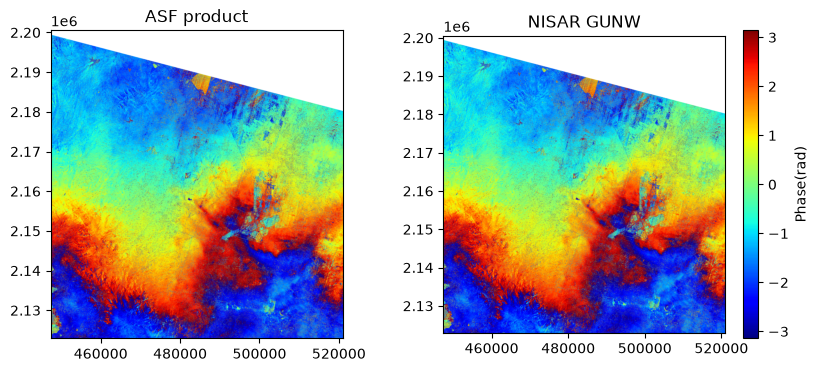

In [6]:
wrap, extent = read_h5('uwg_test/NISAR_L2_OD_GUNW_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05009_N_F_A_001.h5')
wrap_gunw, extent_gunw = read_h5('NISAR_L2_PR_GUNW_004_113_D_079_005_4000_SH_20251106T011330_20251106T011404_20251118T011330_20251118T011405_X05010_N_F_J_001.h5')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_title('ASF product')
im1 = ax1.imshow(wrap, extent = extent, cmap = 'jet')

ax2.set_title('NISAR GUNW')
im2 = ax2.imshow(wrap_gunw, extent = extent_gunw, cmap = 'jet')
ax2.set_xlim(extent[0],extent[1])
ax2.set_ylim(extent[2],extent[3])
fig.colorbar(im2, label='Phase(rad)')